<h4>To perform data augmentation on the abstracts I decided to follow the pipeline above:<h4>
<ol>
<li>Retrieve from MeSH (the official medical vocabulary online) the terms and their synonyms.
<li> Save the predictions in a desc2025.xml file and then parse it.
<li> After parsing the .xml file, save the parsed file in a json file called mesh_synonyms.json.
<li> For each term of the json file compute its embedding using a model, in this case the best one I found is the all-mpnet-base-v2.
<li> I checked the distribution of the cosine similarity between the term and their synonyms. The results suggest that the process of data augmentation may not help so much to improve the training results.
<li> The script augments scientific texts by replacing terms with synonyms. It uses cosine similarity to choose suitable synonyms within a set threshold and adjusts the synonym’s capitalization and plurality to match the original term. The transformation is applied to abstract of the articles, the replacement mapping is printed and the new output file is saved.

In [ ]:
#To perform data augmentation we need the textattack library
!pip install textattack

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 43.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.9 MB/s eta 0:00:00


In [ ]:
import requests

def download_file(url, save_path):
    # Stream the file in chunks
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(save_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

url = "https://nlmpubs.nlm.nih.gov/projects/mesh/MESH_FILES/xmlmesh/desc2025.xml"
save_path = "desc2025.xml"
download_file(url, save_path)
print(f"File downloaded to {save_path}")

File downloaded to desc2025.xml


In [ ]:
import xml.etree.ElementTree as ET
import json

def parse_mesh_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    mesh_dict = {}
    # Iterate over each DescriptorRecord
    for descriptor in root.findall('.//DescriptorRecord'):
        descriptor_name_elem = descriptor.find('./DescriptorName/String')
        if descriptor_name_elem is not None:
            term = descriptor_name_elem.text.strip().lower()
            synonyms = []
            for concept in descriptor.findall('./ConceptList/Concept'):
                for term_elem in concept.findall('./TermList/Term/String'):
                    syn = term_elem.text.strip().lower()
                    if syn != term and syn not in synonyms:
                        synonyms.append(syn)
            if synonyms:
                mesh_dict[term] = synonyms
    return mesh_dict

mesh_synonyms = parse_mesh_xml("desc2025.xml")

#print("terms:")
#for k, v in list(mesh_synonyms.items())[:15]:
   # print(f"{k}: {v}")

with open("mesh_synonyms.json", "w", encoding="utf-8") as outfile:
    json.dump(mesh_synonyms, outfile, ensure_ascii=False, indent=2)

print("file'mesh_synonyms.json'created")


file'mesh_synonyms.json'created


In [ ]:
import os
import re
import os
import pickle
import numpy as np
from sentence_transformers import SentenceTransformer
from textattack.transformations import Transformation

# Function to compute embeddings for each term and its synonyms.
model1="all-MiniLM-L6-v2" #performance sentence:68.06
model2="all-mpnet-base-v2" #performance sentence:69.57
model3="all-MiniLM-L12-v2"#performance sentence:68.70
def compute_embeddings(mesh_dict, model_name):
    model = SentenceTransformer(model_name)
    mesh_embeddings = {}
    for term, synonyms in mesh_dict.items():
        term_embedding = model.encode(term, convert_to_numpy=True)
        synonym_embeddings = {}
        for syn in synonyms:
            synonym_embeddings[syn] = model.encode(syn, convert_to_numpy=True)
        mesh_embeddings[term] = {"term": term_embedding, "syn": synonym_embeddings}
        #print(f"Embeddings computed for term: {term}")
        #print(f"Embeddings computed for synonyms: {synonyms}")
    return mesh_embeddings

embeddings_file = "mesh_embeddingsv1.pkl"

if os.path.exists(embeddings_file):
    with open(embeddings_file, "rb") as f:
        mesh_embeddings = pickle.load(f)
    print("Loaded precomputed mesh embeddings from file.")
else:
    mesh_embeddings = compute_embeddings(mesh_synonyms, model1)
    with open(embeddings_file, "wb") as f:
        pickle.dump(mesh_embeddings, f)
    print("Computed and saved mesh embeddings to file.")

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set i

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computed and saved mesh embeddings to file.


In [ ]:
#i want to check the emdedding file:
import pickle


with open('/content/mesh_embeddingsv1.pkl', 'rb') as f:
    data = pickle.load(f)

print(type(data))
#print("this is the content of the dictionary")

last_five = list(data.items())[-5:]
for key, value in last_five:
    print(key, value)

<class 'dict'>
non-fungible tokens {'term': array([-9.19054374e-02, -3.73026207e-02,  8.75967927e-03,  3.27867866e-02,
       -4.05677548e-03, -3.63245420e-02,  2.07004491e-02, -4.09498028e-02,
        7.53076822e-02, -3.78906471e-03,  2.69784760e-02, -3.49119231e-02,
        3.48702446e-02,  3.42063159e-02,  7.65162259e-02,  2.88327113e-02,
        7.76347937e-03,  8.04572329e-02, -7.50543103e-02,  2.27645622e-03,
        5.44733293e-02,  2.77311224e-02, -5.31489812e-02,  8.08462128e-02,
        1.20509602e-02,  6.71827141e-03,  4.14950447e-03, -7.00061470e-02,
        1.17706563e-02, -2.28031930e-02, -4.44712937e-02,  6.52851611e-02,
       -3.55650000e-02,  3.14172581e-02,  8.70037749e-02,  7.52818063e-02,
        1.10018924e-02,  4.68447879e-02,  1.18900128e-01, -8.59489441e-02,
       -2.34957021e-02, -4.82254177e-02, -6.55722693e-02,  5.86765781e-02,
        1.67187268e-03,  4.69862036e-02,  4.51221801e-02, -1.47943096e-02,
       -1.04735136e-01, -3.85914296e-02,  1.59626249e-02

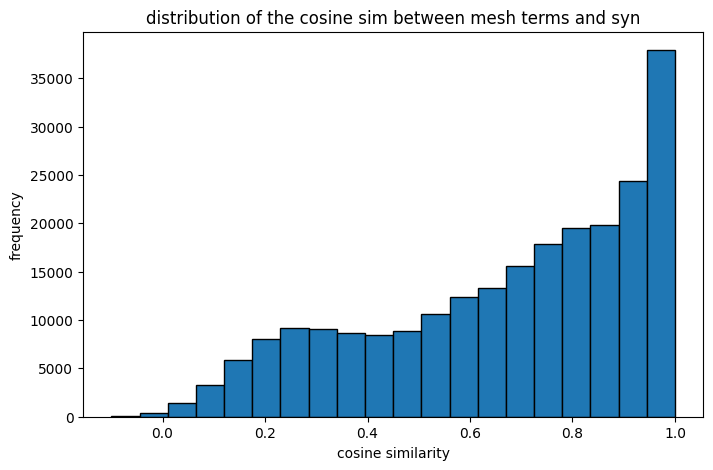

In [ ]:
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

def cosine_similarity(vec1, vec2):
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return np.dot(vec1, vec2) / (norm1 * norm2)

#load datasets
with open("mesh_synonyms.json", "r", encoding="utf-8") as f:
    mesh_dict = json.load(f) #dict

with open("mesh_embeddingsv1.pkl", "rb") as f:
    mesh_embeddings = pickle.load(f) #file with the embeddings

all_similarities = []

for term, synonyms in mesh_dict.items():
    if term not in mesh_embeddings or "term" not in mesh_embeddings[term]:
        continue
    term_emb = mesh_embeddings[term]["term"]
    sims = []
    for syn in synonyms:
        syn_emb = mesh_embeddings[term]["syn"].get(syn)
        if syn_emb is None:
            continue
        sim = cosine_similarity(term_emb, syn_emb)
        sims.append(sim)
        #print(f"term: {term}, syn: {syn}, similarity: {sim:.4f}")
    if sims:
        avg_sim = np.mean(sims)
        #print(f"--> mean sim '{term}': {avg_sim:.4f}\n")
        all_similarities.extend(sims)

plt.figure(figsize=(8, 5))
plt.hist(all_similarities, bins=20, edgecolor="k")
plt.xlabel("cosine similarity")
plt.ylabel("frequency")
plt.title("distribution of the cosine sim between mesh terms and syn")
plt.show()


In [ ]:
import re
import os
import pickle
import json
import numpy as np
import random
import inflect
from sentence_transformers import SentenceTransformer
from textattack.transformations import Transformation

# Initialize inflect engine for morphological adjustments.
p = inflect.engine()

def cosine_similarity(vec1, vec2):
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return np.dot(vec1, vec2) / (norm1 * norm2)

def adjust_replacement(matched_text, chosen_synonym):
#check on the synonymn to replace and make controls over the matched text
    if matched_text.isupper():
        chosen_synonym = chosen_synonym.upper()
    elif matched_text[0].isupper():
        chosen_synonym = chosen_synonym.capitalize() #i need to capitalize it
    #check if i have the word that is composed of more one than it
    words = matched_text.split()
    if words and p.singular_noun(words[-1]):
        syn_words = chosen_synonym.split()
        if syn_words:
            syn_words[-1] = p.plural(syn_words[-1])
            chosen_synonym = " ".join(syn_words)
    return chosen_synonym

def probabilistic_transformation(text, transformation, replacement_probability=0.5):
    augmented_text = text
    # Dictionary to memorize the term and the chosen synonym.
    replacement_mapping = {}

    # Process terms in descending order of length (to avoid partial overlaps).
    for term in sorted(transformation.mesh_dict.keys(), key=len, reverse=True):
        # Skip blacklisted terms.
        if term in transformation.blacklist:
            continue

        pattern = re.compile(r'\b' + re.escape(term) + r'\b', flags=re.IGNORECASE)

        if pattern.search(augmented_text):
            # Decide if we apply the replacement at all for this term.
            if random.random() < replacement_probability:
                candidate_synonyms = []
                original_embedding = transformation.mesh_embeddings.get(term, {}).get("term")
                if original_embedding is None:
                    continue

                # Gather synonyms within [min_similarity, max_similarity].
                for syn in transformation.mesh_dict[term]:
                    syn_embedding = transformation.mesh_embeddings[term]["syn"].get(syn)
                    if syn_embedding is None:
                        continue
                    sim = cosine_similarity(original_embedding, syn_embedding)
                    #Debug
                    #if transformation.debug:
                    #     print(f"Term: {term}, Synonym: {syn}, Similarity: {sim:.4f}")
                    if transformation.min_similarity <= sim <= transformation.max_similarity:
                        candidate_synonyms.append((syn, sim))

                if candidate_synonyms:
                    # Random choice if enabled, otherwise take the synonym with the maximum similarity.
                    if transformation.random_choice:
                        chosen_syn, sim_val = random.choice(candidate_synonyms)
                    else:
                        chosen_syn, sim_val = max(candidate_synonyms, key=lambda x: x[1])

                    if transformation.debug:
                        print(f"Probabilistically replacing '{term}' with '{chosen_syn}' (Similarity: {sim_val:.4f})")

                    # Memorize the chosen synonym for this term.
                    replacement_mapping[term] = chosen_syn

                    # Replace all occurrences of the term in augmented_text.
                    augmented_text = pattern.sub(lambda m: adjust_replacement(m.group(0), chosen_syn), augmented_text)
    return augmented_text, replacement_mapping


class MeshSynonymReplacementTransformation(Transformation):
    def __init__(self, mesh_dict, mesh_embeddings, min_similarity=0.70, max_similarity=0.85, random_choice=True, debug=False, blacklist=None):

        self.mesh_dict = mesh_dict
        self.mesh_embeddings = mesh_embeddings
        self.min_similarity = min_similarity
        self.max_similarity = max_similarity
        self.random_choice = random_choice
        self.debug = debug
        self.blacklist = set(blacklist) if blacklist else set()

    def _get_transformations(self, text, indices=None):
        return [probabilistic_transformation(text, self, replacement_probability=0.9)]

if __name__ == "__main__":
    with open("/content/mesh_synonyms.json", "r", encoding="utf-8") as f:
        mesh_dict = json.load(f)

    with open('/content/mesh_embeddingsv1.pkl', 'rb') as f:
        mesh_embeddings = pickle.load(f)

    #words that are not going to be substituted
    blacklist = []

    transformation = MeshSynonymReplacementTransformation(
        mesh_dict,
        mesh_embeddings,
        min_similarity=0.60,
        max_similarity=0.80,
        random_choice=True,
        debug=True,
        blacklist=blacklist
    )

    #sample_text = "Bacteria in the gut microbiome play an intrinsic part in immune activation, intestinal permeability, enteric reflex, and entero-endocrine signaling. The gut microbiota communicates with the central nervous system (CNS) through the production of bile acids, short-chain fatty acids (SCFAs), glutamate (Glu), \u03b3-aminobutyric acid (GABA), dopamine (DA), norepinephrine (NE), serotonin (5-HT), and histamine. A vast number of signals generated in the gastrointestinal tract (GIT) reach the brain via afferent fibers of the vagus nerve (VN). Signals from the CNS are returned to entero-epithelial cells (EES) via efferent VN fibers and communicate with 100 to 500 million neurons in the submucosa and myenteric plexus of the gut wall, which is referred to as the enteric nervous system (ENS). Intercommunications between the gut and CNS regulate mood, cognitive behavior, and neuropsychiatric disorders such as autism, depression, and schizophrenia. The modulation, development, and renewal of nerves in the ENS and changes in the gut microbiome alter the synthesis and degradation of neurotransmitters, ultimately influencing our mental health. The more we decipher the gut microbiome and understand its effect on neurotransmission, the closer we may get to developing novel therapeutic and psychobiotic compounds to improve cognitive functions and prevent mental disorders. In this review, the intricate control of entero-endocrine signaling and immune responses that keep the gut microbiome in a balanced state, and the influence that changing gut bacteria have on neuropsychiatric disorders, are discussed."

    #augmented_text = probabilistic_transformation(sample_text, transformation, replacement_probability=0.8)

    #print("Original Text:\n", sample_text)
    #print("\nAugmented Text:\n", augmented_text)

    with open("/content/articles_train_bronze.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    # 2. Itera e modifica gli articoli
    all_article_mappings = {}  # Define this once outside the loop

    for id_articolo, articolo in data.items():
        original_abstract = articolo["abstract"]
        print("ID:", id_articolo)
        print("abstract:", original_abstract)

        if original_abstract:
            augmented_abstract, replacement_mapping = probabilistic_transformation(
                original_abstract, transformation, 0.9
            )
            print("Replacement mapping for article", id_articolo, ":", replacement_mapping)

            # Update the article's abstract
            articolo["abstract"] = augmented_abstract
            # Now update the global mappings dictionary
            all_article_mappings[id_articolo] = replacement_mapping

    # After the loop finishes, write out all mappings at once
    with open("all_replacement_mappings.json", "w", encoding="utf-8") as f:
        json.dump(all_article_mappings, f, indent=4, ensure_ascii=False)


    with open("/content/aug_bronze.json", "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)



Output streaming troncato alle ultime 5000 righe.
Probabilistically replacing 'mental health' with 'hygiene, mental' (Similarity: 0.6262)
Probabilistically replacing 'psychotherapy' with 'psychotherapies' (Similarity: 0.6245)
Probabilistically replacing 'microbiota' with 'microbial community structure' (Similarity: 0.6807)
Probabilistically replacing 'research' with 'research, laboratory' (Similarity: 0.6019)
Probabilistically replacing 'eating' with 'intake, food' (Similarity: 0.6636)
Replacement mapping for article 38613114 : {'executive function': 'executive controls', 'mental health': 'hygiene, mental', 'psychotherapy': 'psychotherapies', 'microbiota': 'microbial community structure', 'research': 'research, laboratory', 'eating': 'intake, food'}
ID: 36672595
abstract: It has been 3 years since the beginning of the SARS-CoV-2 outbreak, however it is as yet little known how to care for the acute COVID-19 and long COVID patients. COVID-19 clinical manifestations are of both pulmonary 

In [ ]:
#SCRIPT TO VERIFY THAT THE DATA AUGMENTATION ALG WORKS WELL

import json

file1 = "/content/aug_dev_nothing.json"
file2 = "/content/aug_dev_nothingv1.json"

def load_json(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

json1 = load_json(file1)
json2 = load_json(file2)

if json1 == json2:
    print("The two JSON files are equal.")
else:
    print("The two JSON files are not equal.")


The two JSON files are not equal.
